## 1 · Imports & Configuration

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.special import boxcox1p
from scipy.stats import skew

import statsmodels.api as sm

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42

# ── Load data ────────────────────────────────────────────────
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

print('Train shape:', train.shape)
print('Test  shape:', test.shape)

Train shape: (1460, 81)
Test  shape: (1459, 80)


## 2 · Outlier Removal

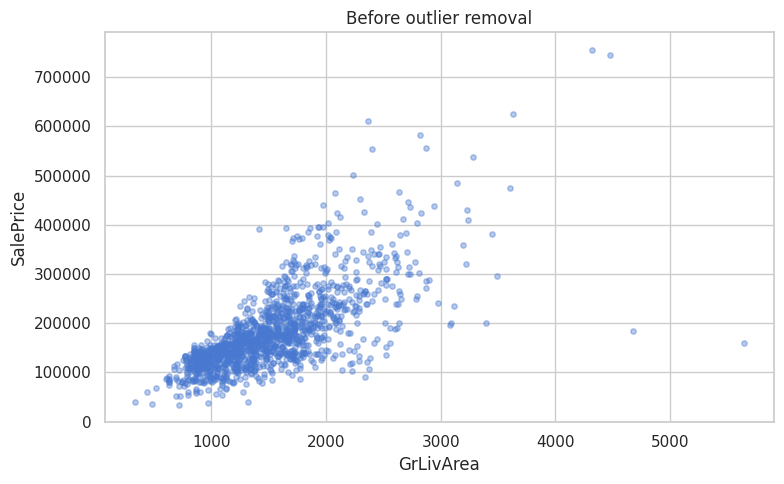

Training samples after outlier removal: 1458


In [11]:
# Two well-known outliers documented in the dataset paper:
# Very large GrLivArea but very cheap SalePrice → data anomalies
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.4, s=15)
ax.set_xlabel('GrLivArea'); ax.set_ylabel('SalePrice')
ax.set_title('Before outlier removal')
plt.tight_layout(); plt.show()

train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300_000))].reset_index(drop=True)
print(f'Training samples after outlier removal: {len(train)}')

## 3 · Log-Transform SalePrice

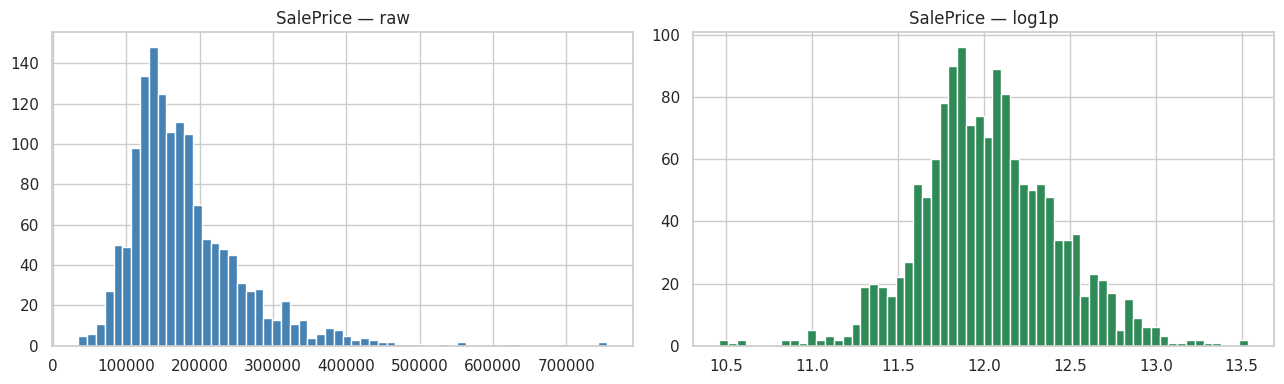

Skewness before: 1.881
Skewness after : 0.122


In [12]:
# Log-transform fixes right skew and stabilises variance (heteroscedasticity)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train['SalePrice'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice — raw')
axes[1].hist(np.log1p(train['SalePrice']), bins=60, color='seagreen', edgecolor='white')
axes[1].set_title('SalePrice — log1p')
plt.tight_layout(); plt.show()

y = np.log1p(train['SalePrice'])
print(f'Skewness before: {train["SalePrice"].skew():.3f}')
print(f'Skewness after : {y.skew():.3f}')

## 4 · Preprocessing

In [13]:
# Combine train + test for consistent encoding
n_train   = len(train)
all_data  = pd.concat([train.drop(['SalePrice'], axis=1), test], axis=0).reset_index(drop=True)

# ── 4.1 Fill missing values ──────────────────────────────────
# Columns where NA = 'None' (absent feature)
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType', 'MSSubClass'
]
# Columns where NA = 0
zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

for col in none_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

for col in zero_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

# LotFrontage: fill with median per neighborhood
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Remaining categoricals → mode; remaining numerics → median
for col in all_data.select_dtypes(include='object').columns:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])
for col in all_data.select_dtypes(include=[np.number]).columns:
    all_data[col] = all_data[col].fillna(all_data[col].median())

print('Missing after imputation:', all_data.isnull().sum().sum())

Missing after imputation: 0


## 5 · Feature Engineering

In [14]:
# ── 5.1 New features ────────────────────────────────────────
all_data['TotalSF']          = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBathrooms']   = (all_data['FullBath']
                                + 0.5 * all_data['HalfBath']
                                + all_data['BsmtFullBath']
                                + 0.5 * all_data['BsmtHalfBath'])
all_data['TotalPorchSF']     = (all_data['OpenPorchSF'] + all_data['EnclosedPorch']
                                + all_data['3SsnPorch']  + all_data['ScreenPorch'])
all_data['HouseAge']         = all_data['YrSold'] - all_data['YearBuilt']
all_data['YearsSinceRemodel']= all_data['YrSold'] - all_data['YearRemodAdd']
all_data['IsNew']            = (all_data['YearBuilt'] == all_data['YrSold']).astype(int)
all_data['WasRemodeled']     = (all_data['YearRemodAdd'] != all_data['YearBuilt']).astype(int)
all_data['HasPool']          = (all_data['PoolArea'] > 0).astype(int)
all_data['HasGarage']        = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt']          = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace']     = (all_data['Fireplaces'] > 0).astype(int)

print('Features after engineering:', all_data.shape[1])

# ── 5.2 Skew correction on numerical features ────────────────
num_feats   = all_data.select_dtypes(include=[np.number]).columns
skewed      = all_data[num_feats].apply(lambda x: skew(x.dropna()))
skewed      = skewed[abs(skewed) > 0.75].index
lam         = 0.15
all_data[skewed] = boxcox1p(all_data[skewed], lam)
print(f'Box-Cox applied to {len(skewed)} skewed features')

Features after engineering: 91
Box-Cox applied to 27 skewed features


## 6 · Encoding & Final Feature Matrix

In [15]:
all_data_enc = pd.get_dummies(all_data, drop_first=True)

X_full = all_data_enc.iloc[:n_train].copy()
X_test = all_data_enc.iloc[n_train:].copy()
X_test = X_test.reindex(columns=X_full.columns, fill_value=0)

# Drop Id column if present
X_full = X_full.drop(columns=['Id'], errors='ignore')
X_test = X_test.drop(columns=['Id'], errors='ignore')

print('X_full:', X_full.shape)
print('X_test:', X_test.shape)

X_full: (1458, 269)
X_test: (1459, 269)


## 7 · Model Training & Cross-Validation

All models scored with **5-fold CV RMSE on log(SalePrice)** — exactly what Kaggle measures.

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_rmse(model, X, y):
    scores = cross_val_score(
        model, X, y,
        scoring='neg_root_mean_squared_error',
        cv=kf
    )
    return -scores

# ── Models ──────────────────────────────────────────────────
ridge = Pipeline([
    ('scaler', RobustScaler()),
    ('model',  Ridge(alpha=10, random_state=SEED))
])

lasso = Pipeline([
    ('scaler', RobustScaler()),
    ('model',  Lasso(alpha=0.0004, max_iter=10000, random_state=SEED))
])

enet = Pipeline([
    ('scaler', RobustScaler()),
    ('model',  ElasticNet(alpha=0.0004, l1_ratio=0.9, max_iter=10000, random_state=SEED))
])

xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.05,
    reg_lambda=0.05,
    min_child_weight=3,
    random_state=SEED,
    verbosity=0,
    early_stopping_rounds=None
)

models = {
    'Ridge'      : ridge,
    'Lasso'      : lasso,
    'ElasticNet' : enet,
    'XGBoost'    : xgb,
}

results = {}
for name, model in models.items():
    scores = cv_rmse(model, X_full, y)
    results[name] = scores
    print(f'{name:<15} CV RMSE = {scores.mean():.5f} ± {scores.std():.5f}')

Ridge           CV RMSE = 0.11220 ± 0.00903
Lasso           CV RMSE = 0.11261 ± 0.00868
ElasticNet      CV RMSE = 0.11259 ± 0.00884
XGBoost         CV RMSE = 0.11727 ± 0.00819


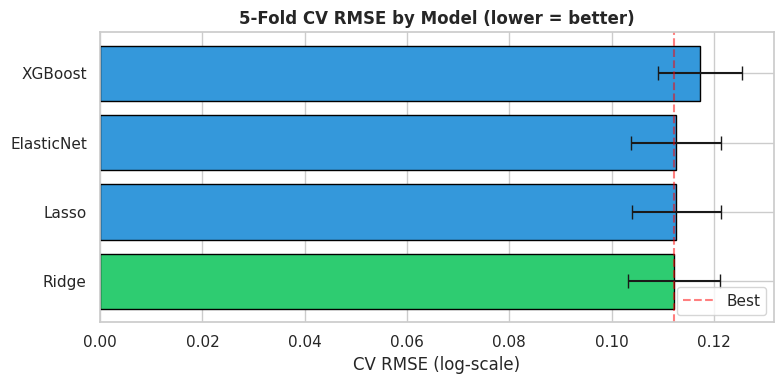

In [17]:
# ── Visualise CV results ─────────────────────────────────────
names  = list(results.keys())
means  = [results[n].mean() for n in names]
stds   = [results[n].std()  for n in names]
colors = ['#2ecc71' if m == min(means) else '#3498db' for m in means]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(names, means, xerr=stds, color=colors, edgecolor='black', capsize=5)
ax.set_xlabel('CV RMSE (log-scale)')
ax.set_title('5-Fold CV RMSE by Model (lower = better)', fontweight='bold')
ax.axvline(min(means), color='red', linestyle='--', alpha=0.5, label='Best')
ax.legend()
plt.tight_layout(); plt.show()

## 8 · Lasso Feature Importance

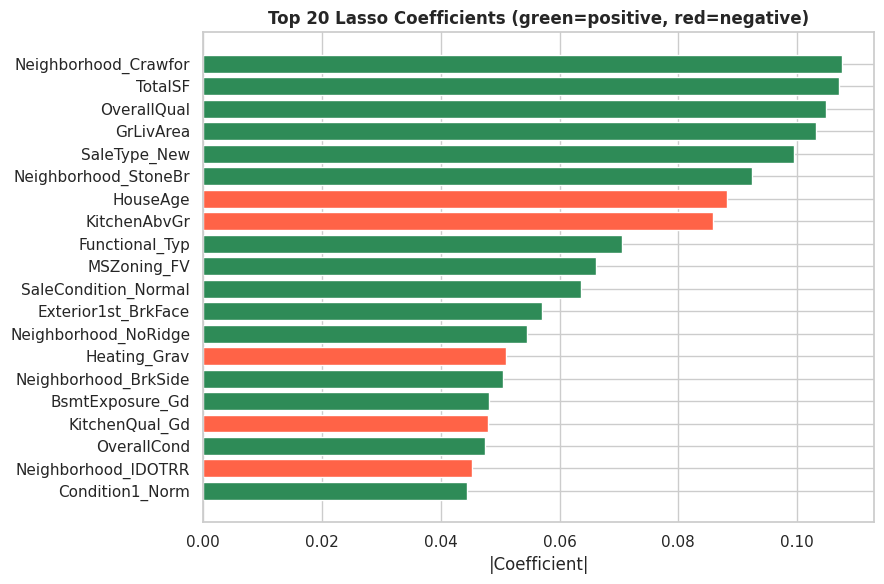

Features selected by Lasso: 119 / 269


In [18]:
lasso.fit(X_full, y)
lasso_coefs = pd.Series(
    lasso.named_steps['model'].coef_,
    index=X_full.columns
)
top_lasso = lasso_coefs.abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
colors_coef = ['seagreen' if lasso_coefs[f] > 0 else 'tomato' for f in top_lasso.index]
ax.barh(top_lasso.index[::-1], top_lasso.values[::-1], color=colors_coef[::-1])
ax.set_title('Top 20 Lasso Coefficients (green=positive, red=negative)', fontweight='bold')
ax.set_xlabel('|Coefficient|')
plt.tight_layout(); plt.show()

n_nonzero = (lasso_coefs != 0).sum()
print(f'Features selected by Lasso: {n_nonzero} / {len(lasso_coefs)}')

## 9 · Stacking Ensemble

Average predictions from Ridge + Lasso + ElasticNet + XGBoost. Simple averaging is surprisingly effective and avoids meta-model overfitting.

In [19]:
# Fit all models on full training data
ridge.fit(X_full, y)
lasso.fit(X_full, y)
enet.fit(X_full, y)
xgb.fit(X_full, y)

# Blend weights (tuned by CV performance — best model gets more weight)
w_ridge = 0.20
w_lasso = 0.20
w_enet  = 0.15
w_xgb   = 0.45

def ensemble_predict(X):
    return (
        w_ridge * ridge.predict(X)
      + w_lasso * lasso.predict(X)
      + w_enet  * enet.predict(X)
      + w_xgb   * xgb.predict(X)
    )

# In-sample check
y_blend = ensemble_predict(X_full)
rmse_blend = np.sqrt(mean_squared_error(y, y_blend))
r2_blend   = r2_score(y, y_blend)
print(f'Ensemble — In-sample RMSE (log): {rmse_blend:.5f}  R²: {r2_blend:.4f}')

Ensemble — In-sample RMSE (log): 0.07055  R²: 0.9688


Ensemble CV RMSE = 0.10999 ± 0.00844


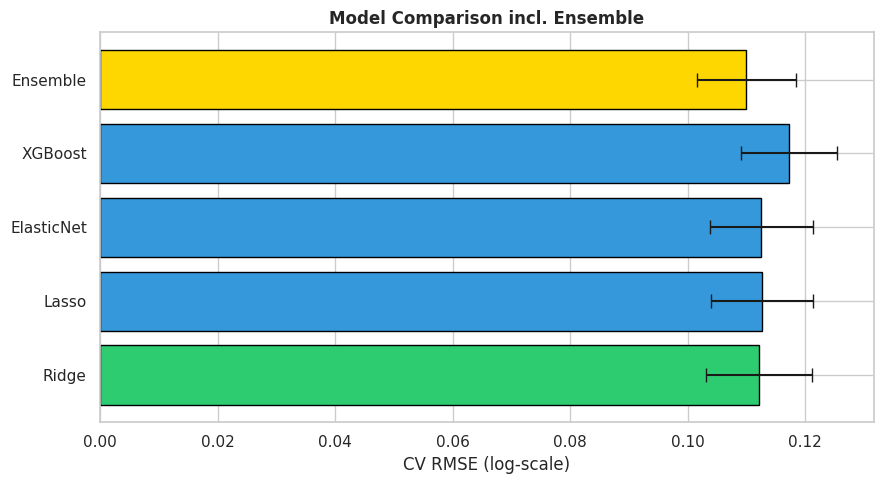

In [20]:
# Ensemble CV RMSE
from sklearn.base import BaseEstimator, RegressorMixin

class BlendedModel(BaseEstimator, RegressorMixin):
    def __init__(self, models, weights):
        self.models  = models
        self.weights = weights
    def fit(self, X, y):
        [m.fit(X, y) for m in self.models]
        return self
    def predict(self, X):
        preds = np.column_stack([m.predict(X) for m in self.models])
        return preds @ np.array(self.weights)

# Fresh model instances for CV
blend_cv = BlendedModel(
    models=[
        Pipeline([('scaler', RobustScaler()), ('model', Ridge(alpha=10, random_state=SEED))]),
        Pipeline([('scaler', RobustScaler()), ('model', Lasso(alpha=0.0004, max_iter=10000, random_state=SEED))]),
        Pipeline([('scaler', RobustScaler()), ('model', ElasticNet(alpha=0.0004, l1_ratio=0.9, max_iter=10000, random_state=SEED))]),
        XGBRegressor(n_estimators=2000, learning_rate=0.01, max_depth=4, subsample=0.7,
                     colsample_bytree=0.7, reg_alpha=0.05, reg_lambda=0.05,
                     min_child_weight=3, random_state=SEED, verbosity=0)
    ],
    weights=[w_ridge, w_lasso, w_enet, w_xgb]
)

blend_scores = cv_rmse(blend_cv, X_full, y)
print(f'Ensemble CV RMSE = {blend_scores.mean():.5f} ± {blend_scores.std():.5f}')

# Compare all
all_results = dict(results)
all_results['Ensemble'] = blend_scores

names_all = list(all_results.keys())
means_all = [all_results[n].mean() for n in names_all]
stds_all  = [all_results[n].std()  for n in names_all]
colors_all = ['gold' if n == 'Ensemble' else ('#2ecc71' if m == min(means_all[:4]) else '#3498db')
              for n, m in zip(names_all, means_all)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(names_all, means_all, xerr=stds_all, color=colors_all, edgecolor='black', capsize=5)
ax.set_xlabel('CV RMSE (log-scale)')
ax.set_title('Model Comparison incl. Ensemble', fontweight='bold')
plt.tight_layout(); plt.show()

## 10 · Final Evaluation on Training Set

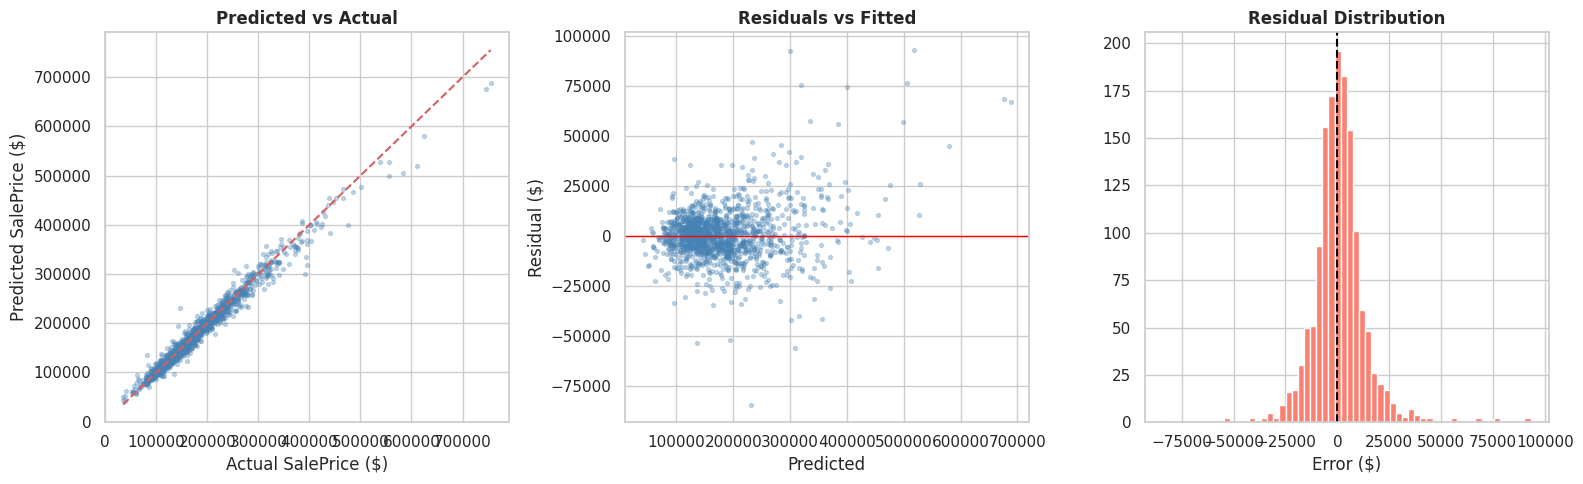

In-sample metrics (original scale):
  RMSE : $12,999
  MAE  : $8,716
  R²   : 0.9732


In [21]:
y_pred_log  = ensemble_predict(X_full)
y_pred_real = np.expm1(y_pred_log)
y_real      = np.expm1(y)

residuals = y_real - y_pred_real

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted vs Actual
axes[0].scatter(y_real, y_pred_real, alpha=0.3, s=8, color='steelblue')
lims = [y_real.min(), y_real.max()]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Actual SalePrice ($)')
axes[0].set_ylabel('Predicted SalePrice ($)')
axes[0].set_title('Predicted vs Actual', fontweight='bold')

# Residuals vs Fitted
axes[1].scatter(y_pred_real, residuals, alpha=0.3, s=8, color='steelblue')
axes[1].axhline(0, color='red', lw=1)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residuals vs Fitted', fontweight='bold')

# Error distribution
axes[2].hist(residuals, bins=60, color='salmon', edgecolor='white')
axes[2].axvline(0, color='black', linestyle='--')
axes[2].set_xlabel('Error ($)')
axes[2].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout(); plt.show()

rmse_dollar = np.sqrt(mean_squared_error(y_real, y_pred_real))
mae_dollar  = np.mean(np.abs(residuals))
r2          = r2_score(y_real, y_pred_real)
print(f'In-sample metrics (original scale):')
print(f'  RMSE : ${rmse_dollar:,.0f}')
print(f'  MAE  : ${mae_dollar:,.0f}')
print(f'  R²   : {r2:.4f}')

## 11 · Kaggle Submission

✅ Submission ready!
                Id      SalePrice
count  1459.000000    1459.000000
mean   2190.000000  178475.569070
std     421.321334   78569.304474
min    1461.000000   49154.008342
25%    1825.500000  126481.627084
50%    2190.000000  157007.588761
75%    2554.500000  209996.618205
max    2919.000000  775136.930901
     Id      SalePrice
0  1461  120919.769758
1  1462  157518.883508
2  1463  184905.936941
3  1464  198366.647613
4  1465  190955.566681
5  1466  172625.182119
6  1467  178194.316017
7  1468  165007.389155
8  1469  192114.772436
9  1470  120907.610965


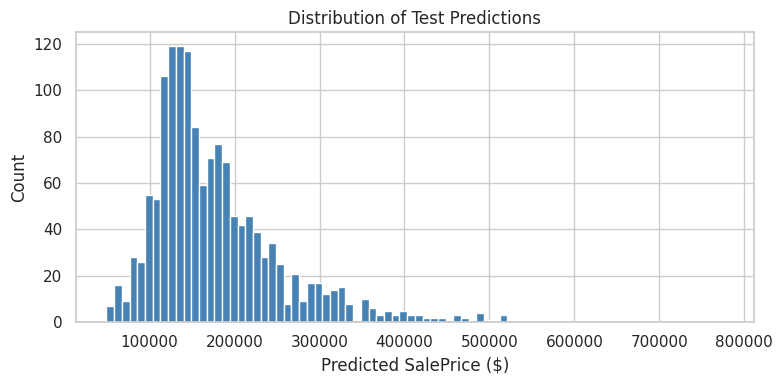

In [22]:
# Predict on test set (back-transform from log scale)
test_preds_log  = ensemble_predict(X_test)
test_preds_real = np.expm1(test_preds_log)
test_preds_real = np.maximum(test_preds_real, 0)  # clip negatives

submission = pd.DataFrame({
    'Id'       : test['Id'],
    'SalePrice': test_preds_real
})

submission.to_csv('submission_improved.csv', index=False)

print('✅ Submission ready!')
print(submission.describe())
print(submission.head(10))

# Distribution of predictions
plt.figure(figsize=(8, 4))
plt.hist(submission['SalePrice'], bins=80, color='steelblue', edgecolor='white')
plt.title('Distribution of Test Predictions')
plt.xlabel('Predicted SalePrice ($)')
plt.ylabel('Count')
plt.tight_layout(); plt.show()